# 15_正则化方法-正则化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/house-prices-advanced-regression-techniques/test.csv`、`dataset/house-prices-advanced-regression-techniques/train.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 缺失值、编码和标准化放入 Pipeline；调参使用更适合目标量纲的 alpha 范围。Lasso 路径使用 warm_start，并仅展示系数幅度最大的 12 个特征。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿咱们来聊一个非常重要的内容：正则化！\~

很多初学者会对正则化理解不透彻，看了本篇文章，一定会有一个新的认识。

先举个简单的例子，大家理解一下\~

当你在学习如何骑自行车。在刚开始的时候，你可能会有很多小动作，比如不停地调整方向或车速，这样你觉得能保持平衡。但是随着你骑得越来越多，你会发现不需要做这么多小动作，反而简单、稳定的骑行更能让你保持平衡。

同样，在训练机器学习模型时，模型一开始可能会记住所有训练数据的细节，这就像你不停地做小动作，这样虽然在训练数据上表现很好，但遇到新数据时却容易“摔车”，也就是泛化能力变差。为了避免这种情况，正则化方法会告诉模型：“别学得太复杂，学点简单、稳定的东西就好。” 这样即使模型对训练数据的“记忆”少了一些，但它在新数据上的表现会更好。

正则化方法（Regularization Techniques）是一种在机器学习模型训练过程中用于防止过拟合的方法。它通过在模型的损失函数中添加一个惩罚项，来限制模型参数的过度复杂化，从而提高模型在新数据上的泛化能力。

正则化的方法有很多种，比如 L1 正则化、L2 正则化、Dropout 等，每种方法都通过不同的方式来控制模型的复杂度，帮助模型学得更加稳健。

## 理论基础

### 数学原理

正则化方法的核心思想是在模型的损失函数中加入一个**惩罚项**，这个惩罚项与模型参数的大小有关。

通过调整惩罚项的权重，控制模型的复杂度，从而避免过拟合。常用的正则化方法有 **L1 正则化** 和 **L2 正则化**。

#### 1. **L2 正则化（Ridge Regression）**

L2 正则化在损失函数中加入了模型参数（权重）的平方和惩罚项。假设我们有一个线性回归模型：


$$
y = \mathbf{w}^T\mathbf{x} + b
$$


其中，$\mathbf{w}$ 是权重向量，$\mathbf{x}$ 是输入特征向量，$b$ 是偏置项，$y$ 是预测值。

对于给定的训练集 $\{ (\mathbf{x}_i, y_i) \}_{i=1}^n$，模型的原始损失函数（比如均方误差损失）为：


$$
\text{Loss} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (\mathbf{w}^T\mathbf{x}_i + b) \right)^2
$$


在 L2 正则化下，损失函数变为：


$$
\text{Loss}_{L2} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (\mathbf{w}^T\mathbf{x}_i + b) \right)^2 + \lambda \|\mathbf{w}\|_2^2
$$


其中，$\|\mathbf{w}\|_2^2$ 是权重向量的 L2 范数的平方：


$$
\|\mathbf{w}\|_2^2 = \sum_{j=1}^{m} w_j^2
$$


$\lambda$ 是正则化强度的超参数，控制正则化项的影响程度。

**效果**：增加了权重值的平方和，使得模型倾向于将权重尽可能小化，但不至于让它们变为零。适用于避免多重共线性问题。

#### 2. **L1 正则化（Lasso Regression）**

L1 正则化在损失函数中加入了模型参数的绝对值和惩罚项。对应的损失函数为：


$$
\text{Loss}_{L1} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (\mathbf{w}^T\mathbf{x}_i + b) \right)^2 + \lambda \|\mathbf{w}\|_1
$$


其中，$\|\mathbf{w}\|_1$ 是权重向量的 L1 范数：


$$
\|\mathbf{w}\|_1 = \sum_{j=1}^{m} |w_j|
$$


**效果**：L1 正则化倾向于使部分权重变为零，从而实现特征选择。这在高维度数据中特别有用，可以通过稀疏性降低模型复杂度。

#### 3. **Elastic Net 正则化**

Elastic Net 是 L1 和 L2 正则化的组合，损失函数如下：


$$
\text{Loss}_{\text{ElasticNet}} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (\mathbf{w}^T\mathbf{x}_i + b) \right)^2 + \lambda_1 \|\mathbf{w}\|_1 + \lambda_2 \|\mathbf{w}\|_2^2
$$


其中 $\lambda_1$ 和 $\lambda_2$ 是控制 L1 和 L2 正则化项的超参数。

**效果**：同时具有 L1 和 L2 正则化的优点，既能进行特征选择，又能防止模型的参数过大。

### 算法流程

下面以 L2 正则化为例，详细说明加入正则化项后的模型训练流程。

#### 1. **初始化参数**

- 初始化模型的权重 $\mathbf{w}$ 和偏置 $b$。
- 设置正则化强度参数 $\lambda$。

#### 2. **前向传播（计算预测值）**

- 对于每一个训练样本 $\mathbf{x}_i$，计算模型的预测值：


$$
\hat{y}_i = \mathbf{w}^T\mathbf{x}_i + b
$$


#### 3. **计算损失函数**

- 计算包含正则化项的总损失：


$$
\text{Loss}_{L2} = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2 + \lambda \|\mathbf{w}\|_2^2
$$


#### 4. **反向传播（计算梯度）**

- 计算损失函数对每个权重 $\mathbf{w}_j$ 的偏导数（梯度）：


$$
\frac{\partial \text{Loss}_{L2}}{\partial w_j} = -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right) x_{ij} + 2\lambda w_j
$$


- 计算损失函数对偏置 $b$ 的偏导数：


$$
\frac{\partial \text{Loss}_{L2}}{\partial b} = -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)
$$


#### 5. **更新参数**

- 使用梯度下降或其他优化算法更新参数：


$$
w_j \leftarrow w_j - \alpha \frac{\partial \text{Loss}_{L2}}{\partial w_j}
$$


$$
b \leftarrow b - \alpha \frac{\partial \text{Loss}_{L2}}{\partial b}
$$


其中，$\alpha$ 是学习率。

#### 6. **重复迭代**

- 重复步骤 2 到 5，直到损失函数收敛或达到预设的迭代次数。

#### 7. **模型评估**

- 在测试集上评估模型的性能，检查是否避免了过拟合，是否提升了泛化能力。

#### 8. **调节正则化参数**

- 根据模型在验证集上的表现，调整正则化参数 $\lambda$，并重复训练过程，直到找到最优的正则化强度。

以上所有的流程，正则化方法可以有效地控制模型的复杂度，避免过拟合，提高模型在新数据上的表现。

## 完整案例

这里案例中，我们使用Kaggle上的《Ames Housing》数据集，它包含了美国爱荷华州Ames市房屋的详细信息。这个数据集具有更多的特征，可以很好地展示正则化在处理高维数据时的作用。

数据集获取：公众号「深夜努力写Python」后台回复『数据集』进行获取\~

### 1. **导入必要的库和加载数据集**

首先，我们加载和处理Ames Housing数据集。

可以使用 `pandas` 处理数据，使用 `scikit-learn` 进行模型构建和正则化。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# 忽略警告信息
import warnings

# 加载Ames Housing数据集
train_path = DATA_DIR / 'house-prices-advanced-regression-techniques/train.csv'
test_path = DATA_DIR / 'house-prices-advanced-regression-techniques/test.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# 查看数据集的基本信息
print(train_data.info())
print(test_data.info())

# 打印数据集的前几行
print(train_data.head())
print(test_data.head())

# 选择特征和目标变量
X = train_data.drop(columns=['SalePrice', 'Id'])
y = train_data['SalePrice']

# 先划分；填补、编码和缩放都在训练折内部拟合。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 2. **数据标准化**

由于我们有大量的特征，标准化可以确保所有特征在相同的尺度上，从而避免模型受到不同特征尺度的影响。

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
numeric_columns = X.select_dtypes(include='number').columns
categorical_columns = X.select_dtypes(exclude='number').columns
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('fill', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), numeric_columns),
    ('categorical', Pipeline([('fill', SimpleImputer(strategy='constant', fill_value='missing')),
                              ('encode', OneHotEncoder(handle_unknown='ignore'))]), categorical_columns)
])

### 3. **应用正则化模型**

我们将继续尝试 Ridge、Lasso 和 ElasticNet 模型，并通过网格搜索优化正则化参数。

In [4]:
from sklearn.base import clone
estimators = {'Ridge': Ridge(), 'Lasso': Lasso(max_iter=50000),
              'ElasticNet': ElasticNet(max_iter=50000)}
models, results = {}, {}
param_grid = {'model__alpha': np.logspace(1, 4, 10)}
for name, estimator in estimators.items():
    pipeline = Pipeline([('preprocessor', clone(preprocessor)), ('model', estimator)])
    search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error',
                          error_score='raise')
    search.fit(X_train, y_train)
    model = search.best_estimator_
    models[name] = model
    y_train_pred, y_test_pred = model.predict(X_train), model.predict(X_test)
    results[name] = {'Train MSE': mean_squared_error(y_train, y_train_pred),
                     'Test MSE': mean_squared_error(y_test, y_test_pred),
                     'Train R2': r2_score(y_train, y_train_pred),
                     'Test R2': r2_score(y_test, y_test_pred),
                     'Best Alpha': search.best_params_['model__alpha']}
ridge_best, lasso_best, elastic_net_best = models['Ridge'], models['Lasso'], models['ElasticNet']
results_df = pd.DataFrame(results).T
print(results_df)

               Train MSE      Test MSE  Train R2   Test R2  Best Alpha
Ridge       9.470476e+08  1.000638e+09  0.842646  0.856603  215.443469
Lasso       6.347652e+08  8.083376e+08  0.894532  0.884161  215.443469
ElasticNet  2.054923e+09  2.358865e+09  0.658570  0.661961   10.000000


### 4. **数据分析和可视化**

接下来，我们通过可视化分析模型性能，观察正则化效果。

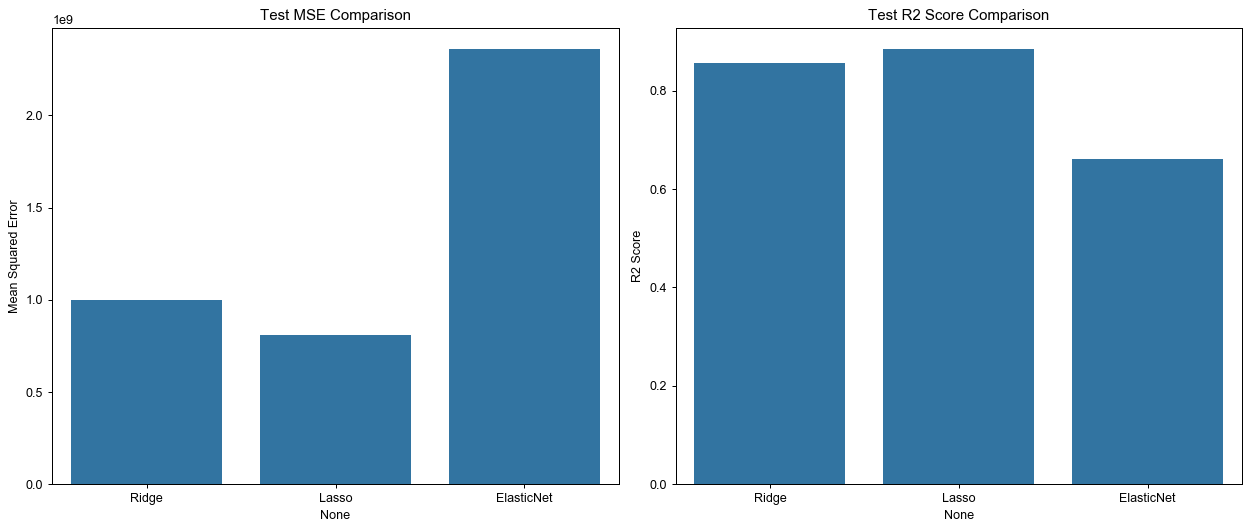

In [5]:
# 可视化模型性能
plt.figure(figsize=(14, 6))

# 绘制 MSE
plt.subplot(1, 2, 1)
sns.barplot(x=results_df.index, y='Test MSE', data=results_df)
plt.title('Test MSE Comparison')
plt.ylabel('Mean Squared Error')

# 绘制 R2 分数
plt.subplot(1, 2, 2)
sns.barplot(x=results_df.index, y='Test R2', data=results_df)
plt.title('Test R2 Score Comparison')
plt.ylabel('R2 Score')

plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

- 通过图表，我们可以看到不同正则化方法在测试集上的表现。
- 低 MSE 和高 R2 表明模型在测试数据上的表现更好。

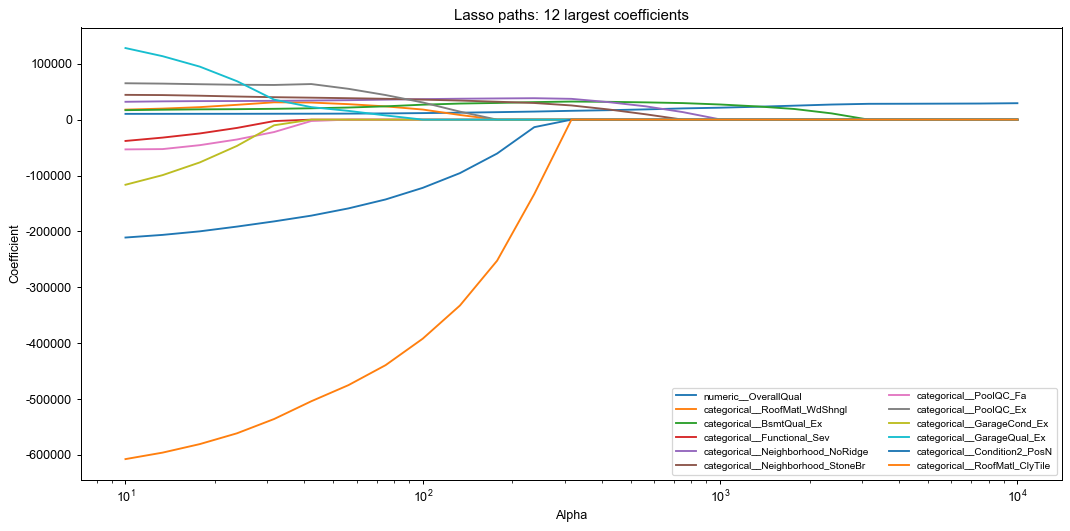

In [6]:
# 在同一训练集上展示正则化路径；从强正则化走向弱正则化。
fitted_preprocessor = lasso_best.named_steps['preprocessor']
X_path = fitted_preprocessor.transform(X_train)
feature_names = fitted_preprocessor.get_feature_names_out()
alphas = np.logspace(4, 1, 25)
path_model = Lasso(max_iter=50000, warm_start=True)
coefs = []
for alpha in alphas:
    path_model.set_params(alpha=alpha)
    path_model.fit(X_path, y_train)
    coefs.append(path_model.coef_.copy())
coefs = np.asarray(coefs)
selected = np.argsort(np.max(np.abs(coefs), axis=0))[-12:]
plt.figure(figsize=(12, 6))
for j in selected:
    plt.plot(alphas, coefs[:, j], label=feature_names[j])
plt.xscale('log'); plt.xlabel('Alpha'); plt.ylabel('Coefficient')
plt.title('Lasso paths: 12 largest coefficients')
plt.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

Lasso 路径图展示了特征的系数如何随着 $\alpha$ 增大而逐渐被压缩为零，说明 Lasso 可以用于特征选择。

#### 算法优化：

1. **超参数调优**：通过更精细的超参数网格和更多的交叉验证，可以进一步优化模型性能。
2. **特征选择**：Lasso 和 ElasticNet 可以自动选择重要的特征，从而简化模型，提高预测性能。

以上，通过Ames Housing数据集的示例，我们展示了如何在高维数据集上应用正则化技术，并分析了不同正则化方法的效果。我们还通过可视化展示了正则化路径，解释了其在特征选择中的作用。这个流程同样适用于更大、更复杂的数据集。

## 模型分析

### 适用问题类型

正则化方法适用于以下类型的问题：

1. **高维数据**：特征数量远大于样本数量（“小样本、大特征”问题），如基因数据、文本数据、图像数据等。高维数据容易导致模型过拟合，正则化可以减少模型的复杂度，防止过拟合。
2. **多重共线性问题**：当输入特征之间存在强烈的线性相关性时，正则化可以稳定回归系数的估计，避免系数不稳定或过大。
3. **模型复杂度控制**：在构建复杂模型（如神经网络）时，正则化可以防止模型学得过于复杂，从而提高其泛化能力。

### 优点

1. **防止过拟合**：通过增加惩罚项，抑制模型参数的大小，减少模型对训练数据的依赖，从而提高对新数据的泛化能力。
2. **模型简化**：L1 正则化可以使一些不重要的特征的权重变为零，从而进行特征选择，简化模型。
3. **稳定性和鲁棒性**：正则化可以增强模型在噪声数据或不完整数据下的鲁棒性，减少模型的波动。
4. **适用于高维数据**：正则化特别适合处理高维数据，可以防止模型过拟合到高维空间中的噪声。

### 缺点

1. **模型偏差引入**：正则化会引入一定的偏差，可能导致模型对某些重要特征的权重估计不足，影响预测效果。
2. **超参数调优复杂**：正则化强度参数（如 $\lambda$）的选择较为敏感，往往需要通过交叉验证等方法进行调优，这增加了模型构建的复杂性。
3. **计算开销**：在非常大的数据集或复杂模型（如深度神经网络）中，正则化的计算会增加模型训练的时间和资源消耗。

### 运用前提条件

1. **高维数据或复杂模型**：正则化特别适合在高维数据集或复杂模型（如神经网络）中使用。
2. **过拟合倾向**：当模型在训练数据上表现良好但在验证或测试数据上表现较差时，正则化可以帮助改善泛化能力。
3. **特征相关性高**：如果特征之间存在较强的相关性（多重共线性），正则化可以帮助稳定模型参数。
4. **需要控制模型复杂度**：当希望控制模型的复杂度或进行特征选择时，正则化是一种有效的方法。

### 实际应用案例

**文本分类**：

- **问题描述**：在文本分类问题中，如垃圾邮件过滤器，常常需要处理数以万计的文本特征（如单词或短语）。这些特征中有很多可能是冗余的或不相关的。
- **应用正则化**：L1 正则化可以自动选择重要的文本特征，将权重较小的特征归零，从而简化模型，提高分类效果。

**图像识别**：

- **问题描述**：在图像识别任务中，神经网络往往需要处理非常高维的像素数据，容易导致模型过拟合。
- **应用正则化**：L2 正则化在训练神经网络时被广泛应用，通过限制权重的大小，防止模型过度拟合训练数据，从而提升对新图像的识别准确率。

**金融风控模型**：

- **问题描述**：在金融风险控制模型中，通常有大量的特征（如用户行为、交易历史等），而这些特征之间可能存在共线性。
- **应用正则化**：通过使用 Elastic Net 正则化，可以同时解决共线性问题并进行特征选择，构建更加稳健的金融风控模型。

## 最后

正则化方法在实际中的用处非常多，无论是提高模型的泛化能力、进行特征选择，还是处理高维数据，正则化都是非常有必要的。